In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import mhnlib.utils as mhn_utils
from math import log, sqrt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
torch.cuda.empty_cache()

In [80]:
dt = 1e-3
num_steps = 1000
num_runs = 5000

x_saved = []
save_every = 10

x = torch.randn((num_runs, 2))

g = 5.0
T = 1e-2
eps = 1.0

noise_strength = sqrt(2 * T * dt)

for step in range(num_steps):
    r2 = torch.sum(x**2, dim=1, keepdim=True)
    force = (1 - g * r2) * x
    force[:, 0] -= eps * x[:, 0]
    force[:, 1] += eps * x[:, 1]
    x = x + force * dt + noise_strength * torch.randn_like(x)
    if step % save_every == 0:
        x_saved.append(x.clone())
x_saved = torch.stack(x_saved, dim=0)

In [96]:
torch.cuda.empty_cache()
quenched_fps = mhn_utils.deterministic_dynamics(x.to('cuda'), 
                                biases= (-0.5*(x**2).sum(dim=-1)).to('cuda'), 
                                betas = torch.logspace(-2,3,10).to('cuda'),
                                x0 = torch.randn((1000,2)).to('cuda'),
                                num_iterations = 1000,).cpu().squeeze(1)

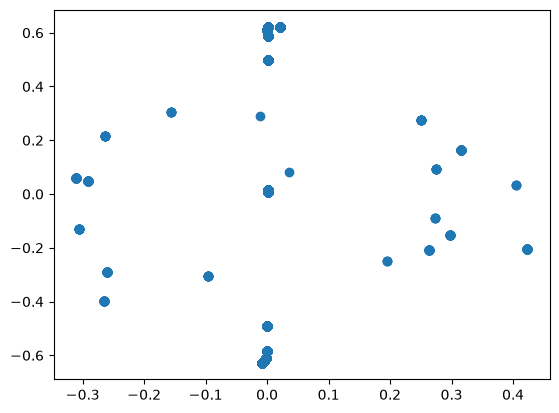

In [97]:
plt.scatter(quenched_fps.reshape(-1, 2)[:, 0], quenched_fps.reshape(-1, 2)[:, 1])

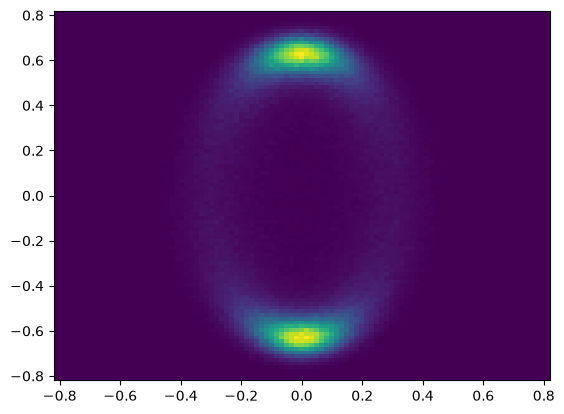

In [78]:
bd = x.abs().max(dim=0).values.max().item()
plt.hist2d(x[:,0], x[:,1], bins=np.linspace(-bd, bd, 100), density=True)
plt.show()